In [7]:
import pandas as pd
import numpy as np

# Read a comma-separated values (csv) file into DataFrame.

The data folder contains a file named "newark_tree_data.csv". Read this file into a dataframe.


resources:
* [Pandas read csv docs](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html#pandas.read_csv)

In [8]:
# Create DataFrame here.
df = pd.read_csv('filename.csv')

In [9]:
# Display the first few rows of the DataFrame here.
print(df.head())

,ID,ON,AREA,ADDRESS,STREET,SITE,SIDE,ASSIGNED,COMMON,BOTANICAL,...,IMPROPMULC,IMPROPPRUN,NUTRIENTD,PEST,GIRDLING,STRESS,OHUTILITY,TOP_HEIGHT,CROWN_M,CROWN_DIE
0,11.0,Elan Park,Elan Park,2,Blue Hen Rg,11.0,Front,False,"arborvitae, eastern",Thuja occidentalis,...,False,False,False,False,False,False,No,40,0-5%,0-5%
1,12.0,Elan Park,Elan Park,2,Blue Hen Rg,12.0,Front,False,"arborvitae, eastern",Thuja occidentalis,...,False,False,False,False,False,False,No,41,0-5%,0-5%
2,13.0,Elan Park,Elan Park,2,Blue Hen Rg,13.0,Front,False,"pine, eastern white",Pinus strobus,...,False,False,False,False,True,False,No,54,0-5%,6-10%
3,14.0,Elan Park,Elan Park,2,Blue Hen Rg,14.0,Front,False,"whitecedar, Atlantic",Chamaecyparis thyoides,...,False,False,False,False,True,False,No,57,11-15%,26-30%
4,15.0,Elan Park,Elan Park,2,Blue Hen Rg,15.0,Front,False,"whitecedar, Atlantic",Chamaecyparis thyoides,...,False,False,False,False,True,False,No,55,11-15%,21-25%


In [10]:
# How many columns does the DataFrame contain?
num_cols = len(df.columns)

54

In [ ]:
# What attributes (columns) does this DataFrame contain?
print(df.dtypes)

In [12]:
# Create the new DataFrame here.
df = pd.read_csv('your_file.csv')

In [13]:
# Display the first few rows of the new DataFrame here.
print(df.head)

,ID,UNIQUEID,COMMON,BOTANICAL,COND,RISK,HEIGHT
0,11.0,LM 20150929141218,"arborvitae, eastern",Thuja occidentalis,Good,Low,40
1,12.0,LM 20150929141418,"arborvitae, eastern",Thuja occidentalis,Very Good,Low,40
2,13.0,LM 20150929141844,"pine, eastern white",Pinus strobus,Good,Low,54
3,14.0,LM 20150929142424,"whitecedar, Atlantic",Chamaecyparis thyoides,Fair,Low,56
4,15.0,LM 20150929143018,"whitecedar, Atlantic",Chamaecyparis thyoides,Fair,Low,55


The data narritive specifies that 4,193 sites were inventoried. Use the DataFrame shape attribute to verify the number of rows.

In [14]:
# How many rows does your DataFrame contain.
len(new_df)


4193

Let's look at the distribution of data for the HEIGHT attribute.

In [15]:
# What is the min height?
new_df["HEIGHT"].min()


np.int64(0)

In [16]:
# What is the max height?
new_df["HEIGHT"].max()


np.int64(140)

In [17]:
# How do we acquire count, mean, standard deviation, and distribution information from the DataFrame 
# by invoking a single method?
new_df.describe()

,ID,HEIGHT
count,4193.000000,4193.000000
mean,2097.000000,55.311472
std,1210.559168,36.293489
min,1.000000,0.000000
25%,1049.000000,23.000000
50%,2097.000000,50.000000
75%,3145.000000,86.000000
max,4193.000000,140.000000


# Plot a histogram using the HEIGHT attribute. 

resources:
* [Magic commands](https://ipython.readthedocs.io/en/stable/interactive/magics.html)
* [Pandas Series Hist](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.plot.hist.html#pandas.Series.plot.hist)

In [18]:
# Apply magic command to display matplotlib images inline
%matplotlib inline


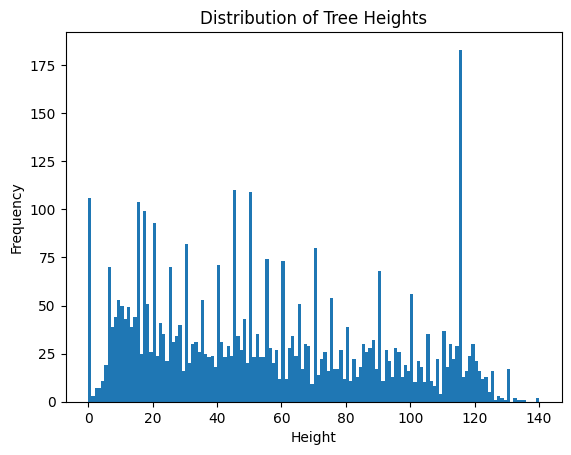

In [46]:
# Create a histogram using the HEIGHT attribute here
import matplotlib.pyplot as plt
plt.hist(new_df["HEIGHT"], bins=140)
plt.xlabel("Height")
plt.ylabel("Frequency")
plt.title("Distribution of Tree Heights")
plt.show()

The data narrative specifies the following:
"A total of 4,193 sites were inventoried, including 4,087 trees, 100 stumps, and 6 vacant planting sites"

Earlier, we were able to validate the total number of entries in the DataFrame. Let's now dig in a bit deeper and validate the stumps and vacant planting sites.

In [45]:
# How many entries are stumps
stumps = new_df[new_df["COMMON"] == "stump"]
len(stumps)


100

In [44]:
# How many entries are vacant sites
vacant_sites = new_df[new_df["COMMON"] == "vacant site, large"]
len(vacant_sites)


6

In [47]:
# Do these number add up?
trees = len(new_df) - len(stumps) - len(vacant_sites)
print(f"Trees: {trees}, Stumps: {len(stumps)}, Vacant: {len(vacant_sites)}, Total: {len(new_df)}")


Trees: 4087, Stumps: 100, Vacant: 6, Total: 4193


# Plot a bar graph using the COND attribute.

resources:
* [Pandas Series Bar](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.plot.bar.html#pandas.Series.plot.bar)

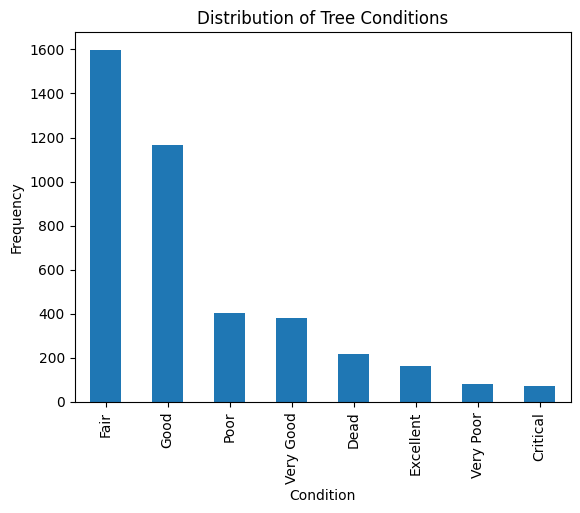

In [49]:
# How can we determine all of the possible values describing the condition of a tree and their associated counts?

cond_counts = new_df["COND"].value_counts()
cond_counts.plot.bar()
plt.xlabel("Condition")
plt.ylabel("Frequency")
plt.title("Distribution of Tree Conditions")
plt.show()


In [55]:
# Were these already in the order you would want them to be in order for a graph to make sense? 
# If not, reorder  the Series.

cond_counts = cond_counts.reindex(["Dead", "Very Poor", "Poor", "Fair", "Good", "Very Good", "Excellent"])



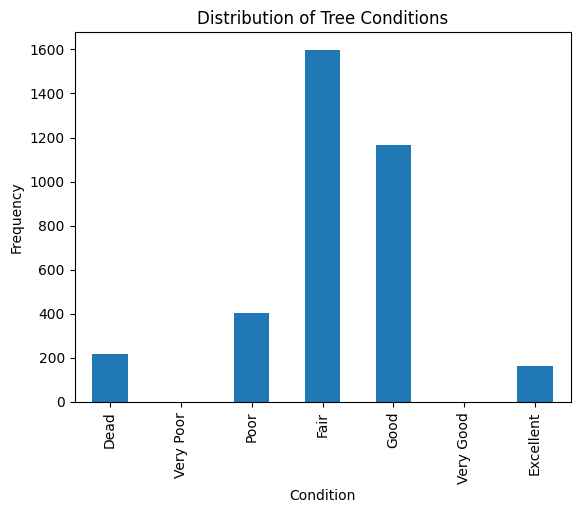

In [56]:
# Plot the Series here
cond_counts.plot.bar()
plt.xlabel("Condition")
plt.ylabel("Frequency")
plt.title("Distribution of Tree Conditions")
plt.show()


In [58]:
# How many entries have missing values for the COND attribute? Why are these values missing?
missing_cond = new_df[new_df["COND"].isna()]
print(f"Missing COND values: {len(missing_cond)}")
print(f"\nThese are missing because they are not LIVING trees:")
print(missing_cond["COMMON"].value_counts())

Missing COND values: 106

These are missing because they are not LIVING trees:
COMMON
stump                 100
vacant site, large      6
Name: count, dtype: int64


# Plot a pie chart using the RISK attribute.

resources:
* [Pandas Series Pie](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.plot.pie.html#pandas.Series.plot.pie)
* [matplotlib pie chart docs](https://matplotlib.org/api/pyplot_api.html#matplotlib.pyplot.pie)

In [59]:
# How can we determine all of the possible values describing the RISK associated with each tree
# along with the corresponding row counts?
risk_counts = new_df["RISK"].value_counts()
risk_counts

RISK
Low         3833
Moderate     241
High          13
Name: count, dtype: int64

In [62]:
# Create an array containing the colors green, yellow, and orange
# When we create our pie chart, the colors should be associated with the attributes according to the specifications below:
# Green -> Low
# Yellow -> Moderate
# Orange -> High
colors = ["green", "yellow", "orange"]


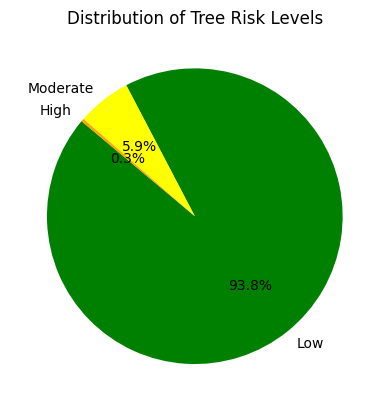

In [63]:
# Plot the pie chart here
plt.pie(risk_counts, labels=risk_counts.index, colors=colors, autopct="%1.1f%%", startangle=140)
plt.title("Distribution of Tree Risk Levels")
plt.show()


In [64]:
# How many entries have missing values for the RISK attribute? Why are these values missing?
missing_risk = new_df[new_df["RISK"].isna()]
print(f"Missing RISK values: {len(missing_risk)}")
print(f"\nThese are missing because they are not LIVING trees:")
print(missing_risk["COMMON"].value_counts())


Missing RISK values: 106

These are missing because they are not LIVING trees:
COMMON
stump                 100
vacant site, large      6
Name: count, dtype: int64


# Indexing

In [65]:
# Display row by position 1
new_df.iloc[1]

ID                          12.0
UNIQUEID       LM 20150929141418
COMMON       arborvitae, eastern
BOTANICAL     Thuja occidentalis
COND                   Very Good
RISK                         Low
HEIGHT                        40
Name: 1, dtype: object

In [66]:
# Display row by label 1
new_df.loc[1]

ID                          12.0
UNIQUEID       LM 20150929141418
COMMON       arborvitae, eastern
BOTANICAL     Thuja occidentalis
COND                   Very Good
RISK                         Low
HEIGHT                        40
Name: 1, dtype: object